# Optimización Numérica en una Dimensión

Notebook corregido para cumplir la consigna: implementación, verificación, función no trivial, ajuste de datos y bonus.

## Configuración básica

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from abstractions.base import Function
from abstractions.functions import Variable, sin, cos, exp, ln

x = Variable()


Matplotlib is building the font cache; this may take a moment.


## 1. Implementación de métodos

Los tres métodos buscan extremos de una función. Para bisección y Newton se resuelve $f'(x)=0$. Para descenso por gradiente se actualiza $x_{n+1}=x_n-\alpha f'(x_n)$

In [2]:
def biseccion(f: Function, a: float, b: float, tol: float = 1e-6, max_iter: int = 1000):
    """Busca una raíz de f'(x) en [a,b] usando bisección.
    Devuelve: punto aproximado, lista de aproximaciones.
    """
    g = f.derivative()
    fa = g.eval(a)
    fb = g.eval(b)

    if abs(fa) < tol:
        return a, [a]
    if abs(fb) < tol:
        return b, [b]
    if fa * fb > 0:
        raise ValueError("Bisección requiere cambio de signo en f'(x) dentro del intervalo.")

    steps = []
    for _ in range(max_iter):
        m = (a + b) / 2
        fm = g.eval(m)
        steps.append(m)

        if abs(fm) < tol or abs(b - a) / 2 < tol:
            return m, steps

        if fa * fm < 0:
            b = m
            fb = fm
        else:
            a = m
            fa = fm

    return (a + b) / 2, steps


def newton(f: Function, x0: float, tol: float = 1e-6, max_iter: int = 1000):
    """Newton aplicado a f'(x)=0.
    Devuelve: punto aproximado, lista de aproximaciones.
    """
    g = f.derivative()
    dg = g.derivative()
    x_actual = x0
    steps = [x_actual]

    for _ in range(max_iter):
        gx = g.eval(x_actual)
        dgx = dg.eval(x_actual)

        if abs(dgx) < 1e-12:
            raise ZeroDivisionError("Newton se detuvo porque f''(x) es casi cero.")

        x_nuevo = x_actual - gx / dgx
        steps.append(x_nuevo)

        if abs(x_nuevo - x_actual) < tol or abs(g.eval(x_nuevo)) < tol:
            return x_nuevo, steps

        x_actual = x_nuevo

    return x_actual, steps


def descenso_gradiente(f: Function, x0: float, lr: float = 0.01, tol: float = 1e-6, max_iter: int = 1000):
    """Descenso por gradiente clásico.
    Devuelve: punto aproximado, lista de aproximaciones.
    """
    g = f.derivative()
    x_actual = x0
    steps = [x_actual]

    for _ in range(max_iter):
        grad = g.eval(x_actual)
        x_nuevo = x_actual - lr * grad
        steps.append(x_nuevo)

        if abs(x_nuevo - x_actual) < tol or abs(grad) < tol:
            return x_nuevo, steps

        if not np.isfinite(x_nuevo):
            raise ValueError("El método diverge: apareció un valor no finito.")

        x_actual = x_nuevo

    return x_actual, steps


def clasificar_extremo(f: Function, x_aprox: float, tol: float = 1e-5):
    """Clasifica el punto usando el signo de f''(x)."""
    segunda = f.derivative().derivative().eval(x_aprox)
    if segunda > tol:
        return "mínimo local"
    elif segunda < -tol:
        return "máximo local"
    else:
        return "no concluye"


def ejecutar(nombre_metodo, funcion, parametros):
    """Ejecuta un método y devuelve una fila para tabla."""
    try:
        if nombre_metodo == "Bisección":
            x_aprox, steps = biseccion(funcion, **parametros)
        elif nombre_metodo == "Newton":
            x_aprox, steps = newton(funcion, **parametros)
        elif nombre_metodo == "Descenso por gradiente":
            x_aprox, steps = descenso_gradiente(funcion, **parametros)
        else:
            raise ValueError("Método no reconocido")

        return {
            "Método": nombre_metodo,
            "Condición inicial": str(parametros),
            "Resultado": x_aprox,
            "f(resultado)": funcion.eval(x_aprox),
            "Tipo": clasificar_extremo(funcion, x_aprox),
            "Iteraciones": len(steps) - 1,
            "Estado": "OK",
            "Aproximaciones": steps
        }
    except Exception as e:
        return {
            "Método": nombre_metodo,
            "Condición inicial": str(parametros),
            "Resultado": np.nan,
            "f(resultado)": np.nan,
            "Tipo": "-",
            "Iteraciones": np.nan,
            "Estado": f"Error: {e}",
            "Aproximaciones": []
        }


## 2. Verificación de funcionamiento

La consigna pide probar al menos $x^2$, $(x+1/2)^3-(x+1/2)$ y -$\cos(x)$.

In [3]:
f1 = x**2
f2 = (x + 0.5)**3 - (x + 0.5)
f3 = -cos(x)

pruebas_simples = [
    ("f(x)=x^2", f1, [
        ("Bisección", {"a": -1, "b": 1}),
        ("Newton", {"x0": 1}),
        ("Descenso por gradiente", {"x0": 1, "lr": 0.1}),
    ]),
    ("f(x)=(x+1/2)^3-(x+1/2)", f2, [
        ("Bisección", {"a": -2, "b": -0.5}),
        ("Newton", {"x0": -1}),
        ("Descenso por gradiente", {"x0": -1, "lr": 0.05}),
    ]),
    ("f(x)=-cos(x)", f3, [
        ("Bisección", {"a": -1, "b": 1}),
        ("Newton", {"x0": 1}),
        ("Descenso por gradiente", {"x0": 1, "lr": 0.1}),
    ]),
]

filas = []
for nombre_funcion, funcion, metodos in pruebas_simples:
    for nombre_metodo, parametros in metodos:
        fila = ejecutar(nombre_metodo, funcion, parametros)
        fila["Función"] = nombre_funcion
        filas.append(fila)

tabla_verificacion = pd.DataFrame(filas)
tabla_verificacion[["Función", "Método", "Condición inicial", "Resultado", "f(resultado)", "Tipo", "Iteraciones", "Estado"]]


,Función,Método,Condición inicial,Resultado,f(resultado),Tipo,Iteraciones,Estado
0,f(x)=x^2,Bisección,"{'a': -1, 'b': 1}",0.000000e+00,0.000000e+00,mínimo local,0,OK
1,f(x)=x^2,Newton,{'x0': 1},0.000000e+00,0.000000e+00,mínimo local,1,OK
2,f(x)=x^2,Descenso por gradiente,"{'x0': 1, 'lr': 0.1}",3.741444e-06,1.399840e-11,mínimo local,56,OK
3,f(x)=(x+1/2)^3-(x+1/2),Bisección,"{'a': -2, 'b': -0.5}",-1.077350e+00,3.849002e-01,máximo local,19,OK
4,f(x)=(x+1/2)^3-(x+1/2),Newton,{'x0': -1},-1.077350e+00,3.849002e-01,máximo local,3,OK
5,f(x)=(x+1/2)^3-(x+1/2),Descenso por gradiente,"{'x0': -1, 'lr': 0.05}",7.734566e-02,-3.849002e-01,mínimo local,82,OK
6,f(x)=-cos(x),Bisección,"{'a': -1, 'b': 1}",0.000000e+00,-1.000000e+00,mínimo local,0,OK
7,f(x)=-cos(x),Newton,{'x0': 1},2.923566e-13,-1.000000e+00,mínimo local,4,OK
8,f(x)=-cos(x),Descenso por gradiente,"{'x0': 1, 'lr': 0.1}",8.317204e-06,-1.000000e+00,mínimo local,112,OK


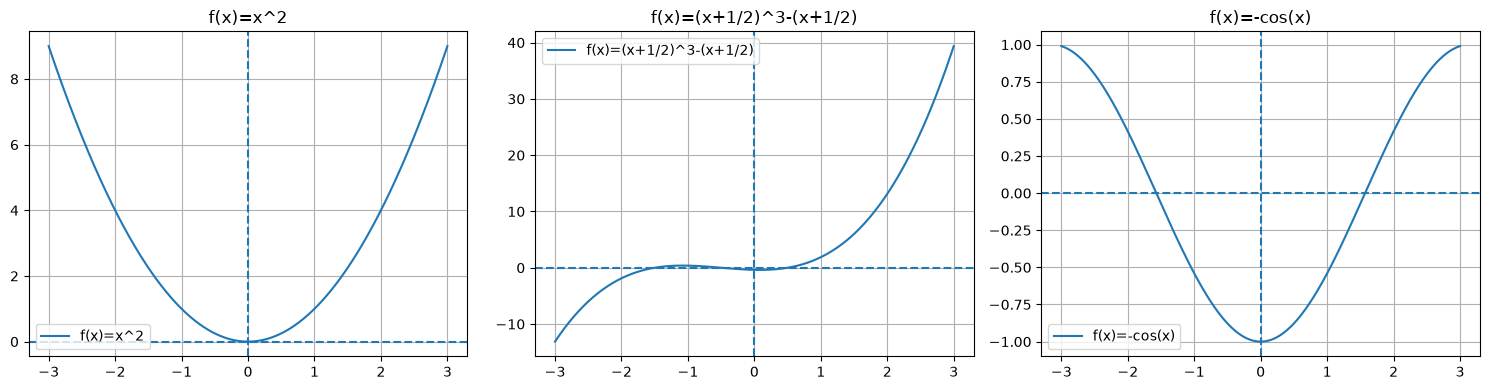

In [4]:
# Gráficos de verificación
lp = np.linspace(-3, 3, 500)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (nombre_funcion, funcion, _) in zip(axes, pruebas_simples):
    ax.plot(lp, [funcion.eval(v) for v in lp], label=nombre_funcion)
    ax.axhline(0, linestyle="--")
    ax.axvline(0, linestyle="--")
    ax.set_title(nombre_funcion)
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()


### Preguntas de la sección 2.3

**¿Pueden estos métodos diferenciar un máximo de un mínimo?**

No directamente. Los métodos aproximan puntos donde $f'(x)=0$ o reducen el valor de la función. Para distinguir si el punto es máximo o mínimo se analiza la segunda derivada: si $f''(c)>0$ es mínimo local y si $f''(c)<0$ es máximo local.

**Ventajas y desventajas:**

- **Bisección:** es estable si hay cambio de signo en $f'(x)$, pero necesita intervalo y puede ser lenta.
- **Newton:** suele converger rápido, pero puede fallar si $f''(x)$ es cero o si el punto inicial no es bueno.
- **Descenso por gradiente:** es simple y útil en problemas de ajuste, pero depende mucho del learning rate.

## 3. Aplicación a una función no trivial

Se estudia $f(x)=x^2+2\sin(3x)$ en el intervalo $[-3,5]$.

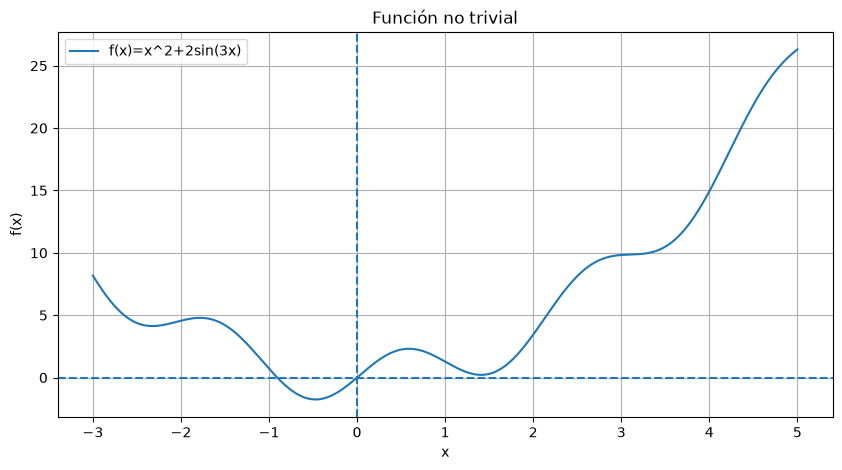

In [5]:
f = x**2 + 2*sin(3*x)

lp = np.linspace(-3, 5, 800)
y = np.array([f.eval(v) for v in lp])

plt.figure(figsize=(10, 5))
plt.plot(lp, y, label="f(x)=x^2+2sin(3x)")
plt.axhline(0, linestyle="--")
plt.axvline(0, linestyle="--")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Función no trivial")
plt.legend()
plt.grid(True)
plt.show()


### Predicción cualitativa

Como la función tiene varios extremos locales, el resultado puede cambiar según el intervalo o punto inicial. Bisección buscará una raíz de $f'(x)$ dentro del intervalo elegido; Newton puede saltar a otro extremo si el punto inicial no es adecuado; descenso por gradiente tenderá a bajar hacia el mínimo local cercano, pero depende del learning rate.

In [6]:
experimentos_no_trivial = []

for intervalo in [(-2, 1), (-1, 0), (1, 2)]:
    experimentos_no_trivial.append(("Bisección", {"a": intervalo[0], "b": intervalo[1]}))

for x0 in [-2, -1, 4]:
    experimentos_no_trivial.append(("Newton", {"x0": x0}))

for x0 in [-3, 0.585, 4]:
    experimentos_no_trivial.append(("Descenso por gradiente", {"x0": x0, "lr": 0.01, "max_iter": 5000}))

filas = []
for nombre_metodo, parametros in experimentos_no_trivial:
    fila = ejecutar(nombre_metodo, f, parametros)
    fila["Predicción"] = "Converge a un extremo local cercano o a una raíz de f'(x) del intervalo"
    filas.append(fila)

tabla_no_trivial = pd.DataFrame(filas)
tabla_no_trivial[["Método", "Condición inicial", "Predicción", "Resultado", "f(resultado)", "Tipo", "Iteraciones", "Estado"]]


,Método,Condición inicial,Predicción,Resultado,f(resultado),Tipo,Iteraciones,Estado
0,Bisección,"{'a': -2, 'b': 1}",Converge a un extremo local cercano o a una ra...,-1.782932,4.787319,máximo local,21,OK
1,Bisección,"{'a': -1, 'b': 0}",Converge a un extremo local cercano o a una ra...,-0.471044,-1.753311,mínimo local,19,OK
2,Bisección,"{'a': 1, 'b': 2}",Converge a un extremo local cercano o a una ra...,1.407956,0.216284,mínimo local,19,OK
3,Newton,{'x0': -2},Converge a un extremo local cercano o a una ra...,-1.782932,4.787319,máximo local,5,OK
4,Newton,{'x0': -1},Converge a un extremo local cercano o a una ra...,0.589531,2.308551,máximo local,4,OK
5,Newton,{'x0': 4},Converge a un extremo local cercano o a una ra...,7.820892,59.176196,mínimo local,1000,OK
6,Descenso por gradiente,"{'x0': -3, 'lr': 0.01, 'max_iter': 5000}",Converge a un extremo local cercano o a una ra...,-2.322813,4.129721,mínimo local,77,OK
7,Descenso por gradiente,"{'x0': 0.585, 'lr': 0.01, 'max_iter': 5000}",Converge a un extremo local cercano o a una ra...,-0.471039,-1.753311,mínimo local,89,OK
8,Descenso por gradiente,"{'x0': 4, 'lr': 0.01, 'max_iter': 5000}",Converge a un extremo local cercano o a una ra...,1.407961,0.216284,mínimo local,180,OK


In [7]:
# Prueba de varios learning rates para descenso por gradiente
learning_rates = [0.001, 0.005, 0.01, 0.05, 0.1]
x0_values = [-3, 0.585, 4]

filas_lr = []
for x0 in x0_values:
    for lr in learning_rates:
        fila = ejecutar("Descenso por gradiente", f, {"x0": x0, "lr": lr, "max_iter": 5000})
        fila["x0"] = x0
        fila["learning rate"] = lr
        filas_lr.append(fila)

tabla_learning_rates = pd.DataFrame(filas_lr)
tabla_learning_rates[["x0", "learning rate", "Resultado", "f(resultado)", "Tipo", "Iteraciones", "Estado"]]


,x0,learning rate,Resultado,f(resultado),Tipo,Iteraciones,Estado
0,-3.000,0.001,-2.322881,4.129721,mínimo local,636,OK
1,-3.000,0.005,-2.322821,4.129721,mínimo local,148,OK
2,-3.000,0.010,-2.322813,4.129721,mínimo local,77,OK
3,-3.000,0.050,-2.322808,4.129721,mínimo local,12,OK
4,-3.000,0.100,-2.322807,4.129721,mínimo local,16,OK
5,0.585,0.001,-0.470994,-1.753311,mínimo local,795,OK
6,0.585,0.005,-0.471035,-1.753311,mínimo local,174,OK
7,0.585,0.010,-0.471039,-1.753311,mínimo local,89,OK
8,0.585,0.050,-0.471043,-1.753311,mínimo local,14,OK
9,0.585,0.100,-0.471043,-1.753311,mínimo local,511,OK


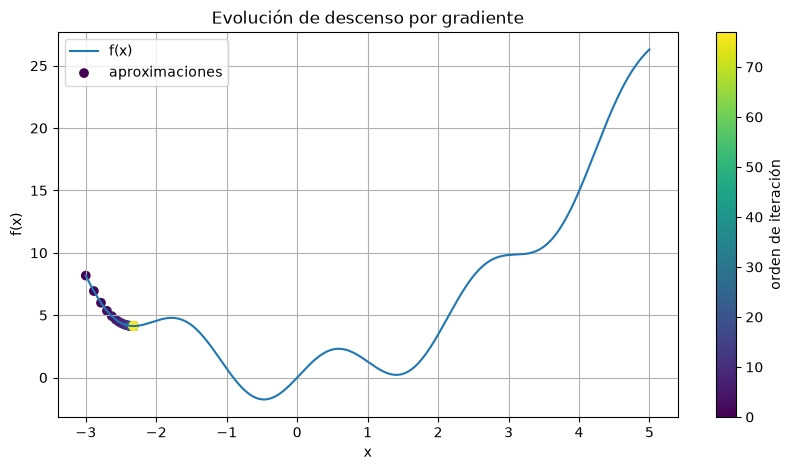

In [8]:
# BONUS visual: graficar puntos de una trayectoria
# Elegimos una trayectoria que haya convergido correctamente.
trayectorias_ok = tabla_no_trivial[
    (tabla_no_trivial["Método"] == "Descenso por gradiente") &
    (tabla_no_trivial["Estado"] == "OK")
]

if len(trayectorias_ok) > 0:
    fila = trayectorias_ok.iloc[0]
    steps = np.array(fila["Aproximaciones"])
    ys_steps = np.array([f.eval(v) for v in steps])

    plt.figure(figsize=(10, 5))
    plt.plot(lp, y, label="f(x)")
    plt.scatter(steps, ys_steps, c=np.arange(len(steps)), label="aproximaciones")
    plt.colorbar(label="orden de iteración")
    plt.xlabel("x")
    plt.ylabel("f(x)")
    plt.title("Evolución de descenso por gradiente")
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("No hay trayectorias correctas para graficar.")


### Preguntas de la sección 3.3

**¿Funcionaron como esperaba?**

En general sí, pero con la advertencia de que cada método puede llegar a extremos distintos porque la función tiene varios extremos locales.

**¿Cómo usar descenso por gradiente para máximos sin cambiar el algoritmo?**

Para maximizar $f$, se minimiza $-f$. Es decir, se aplica el mismo algoritmo sobre la función opuesta.

**¿Hay riesgo de no converger?**

Sí. Si el learning rate es muy grande, el método puede oscilar o divergir. Además, si la función tiene muchas oscilaciones, el punto inicial puede llevar a un extremo local distinto.

## 4. Ajuste de datos mediante optimización

Se ajustan los modelos $\hat y = wx$, $\hat y = e^{wx}$ y $\hat y = \sin(wx)$ minimizando:

$$
L(w)=\frac{1}{N}\sum_{i=1}^{N}(\hat y(x_i;w)-y_i)^2
$$

In [9]:
# Carga de datasets.
# Si los archivos no existen en la carpeta datasets/, se generan datos sintéticos para poder ejecutar el notebook.
try:
    df_linear = pd.read_csv("datasets/linear_model.csv")
    df_exp = pd.read_csv("datasets/exp_model.csv")
    df_sin = pd.read_csv("datasets/sin_model.csv")
    print("Datasets cargados desde la carpeta datasets/.")
except FileNotFoundError:
    print("No se encontró carpeta datasets/. Se generan datos sintéticos de prueba.")
    np.random.seed(42)
    x_data = np.linspace(-2, 2, 50)
    df_linear = pd.DataFrame({"x": x_data, "y": 2.0*x_data + np.random.normal(0, 0.2, len(x_data))})
    df_exp = pd.DataFrame({"x": x_data, "y": np.exp(0.8*x_data) + np.random.normal(0, 0.15, len(x_data))})
    df_sin = pd.DataFrame({"x": x_data, "y": np.sin(1.5*x_data) + np.random.normal(0, 0.10, len(x_data))})

w = Variable()

df_linear.head()


Datasets cargados desde la carpeta datasets/.


,x,y
0,-1.536150,-10.462930
1,-1.757055,3.464101
2,-1.908916,-15.877576
3,8.225895,15.983421
4,-3.201385,-13.311602


In [10]:
def crear_perdida(df, tipo_modelo):
    """Construye L(w) simbólicamente para un dataset y modelo."""
    perdida = 0
    N = len(df)

    for _, fila in df.iterrows():
        xi = float(fila["x"])
        yi = float(fila["y"])

        if tipo_modelo == "lineal":
            y_pred = w * xi
        elif tipo_modelo == "exponencial":
            y_pred = exp(w * xi)
        elif tipo_modelo == "seno":
            y_pred = sin(w * xi)
        else:
            raise ValueError("Modelo no reconocido")

        perdida = perdida + (y_pred - yi)**2

    return perdida / N

perdida_lineal = crear_perdida(df_linear, "lineal")
perdida_exp = crear_perdida(df_exp, "exponencial")
perdida_sin = crear_perdida(df_sin, "seno")

perdidas = {
    "Lineal: y=wx": (perdida_lineal, df_linear, "lineal"),
    "Exponencial: y=e^(wx)": (perdida_exp, df_exp, "exponencial"),
    "Seno: y=sin(wx)": (perdida_sin, df_sin, "seno"),
}


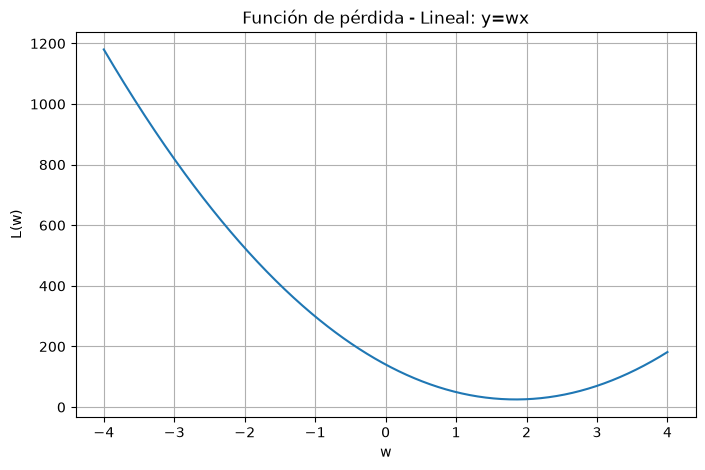

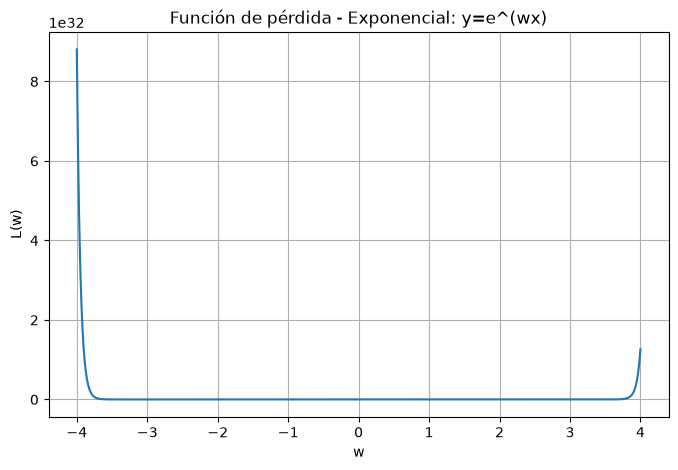

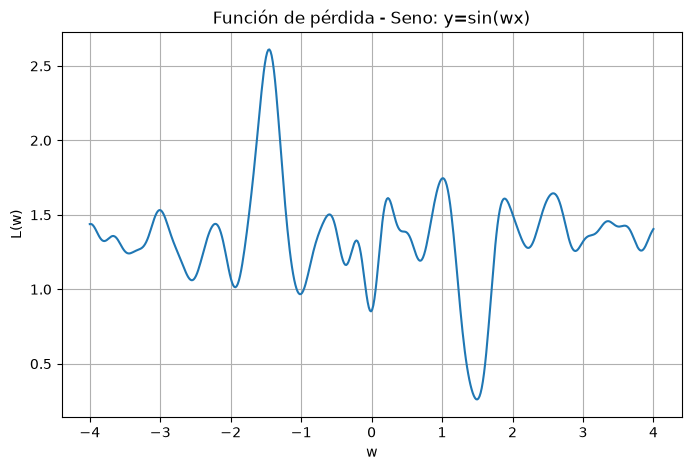

In [11]:
# Graficar L(w) para cada modelo
w_values = np.linspace(-4, 4, 500)

for nombre, (L, df, tipo) in perdidas.items():
    valores = np.array([L.eval(valor) for valor in w_values])

    plt.figure(figsize=(8, 5))
    plt.plot(w_values, valores)
    plt.xlabel("w")
    plt.ylabel("L(w)")
    plt.title(f"Función de pérdida - {nombre}")
    plt.grid(True)
    plt.show()


In [12]:
# Optimizar L(w) usando descenso por gradiente
experimentos_perdida = [
    {"Modelo": "Lineal: y=wx", "w0": 0.0, "lr": 0.05},
    {"Modelo": "Exponencial: y=e^(wx)", "w0": 0.0, "lr": 0.01},
    {"Modelo": "Seno: y=sin(wx)", "w0": 1.0, "lr": 0.01},
]

filas_perdida = []
for experimento in experimentos_perdida:
    nombre = experimento["Modelo"]
    L, df, tipo = perdidas[nombre]

    fila = ejecutar(
        "Descenso por gradiente",
        L,
        {"x0": experimento["w0"], "lr": experimento["lr"], "tol": 1e-8, "max_iter": 10000}
    )
    fila["Modelo"] = nombre
    fila["w inicial"] = experimento["w0"]
    fila["learning rate"] = experimento["lr"]
    filas_perdida.append(fila)

tabla_perdida = pd.DataFrame(filas_perdida)
tabla_perdida[["Modelo", "w inicial", "learning rate", "Resultado", "f(resultado)", "Iteraciones", "Estado"]].rename(columns={"Resultado": "w óptimo", "f(resultado)": "L(w óptimo)"})


/Users/mhc/Desktop/Optimizaci-n-Num-rica-en-una-Dimensi-n/abstractions/functions.py:69: RuntimeWarning: overflow encountered in exp
  return np.exp(self.f.eval(x))
/Users/mhc/Desktop/Optimizaci-n-Num-rica-en-una-Dimensi-n/abstractions/operations.py:47: RuntimeWarning: invalid value encountered in scalar multiply
  return self.f.eval(x) * self.g.eval(x)


,Modelo,w inicial,learning rate,w óptimo,L(w óptimo),Iteraciones,Estado
0,Lineal: y=wx,0.0,0.05,NaN,NaN,NaN,Error: El método diverge: apareció un valor no...
1,Exponencial: y=e^(wx),0.0,0.01,NaN,NaN,NaN,Error: El método diverge: apareció un valor no...
2,Seno: y=sin(wx),1.0,0.01,0.689766,1.191344,62.0,OK


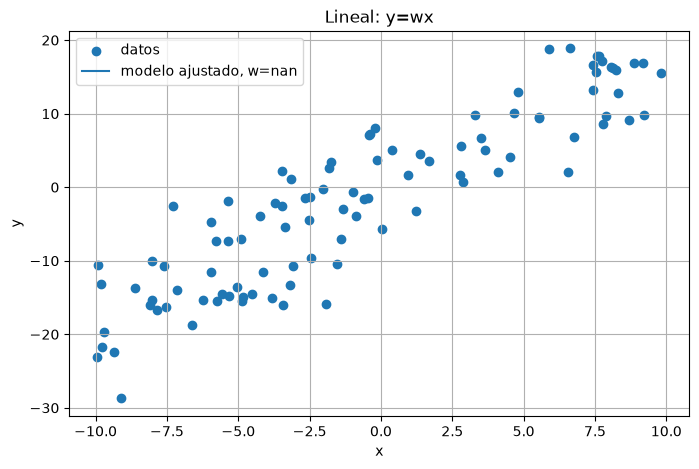

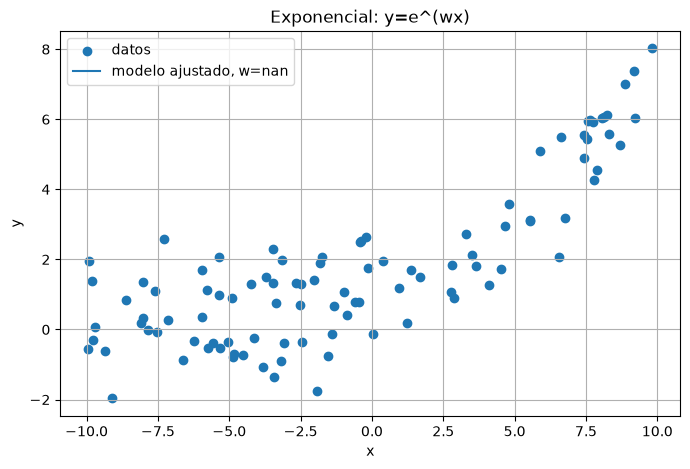

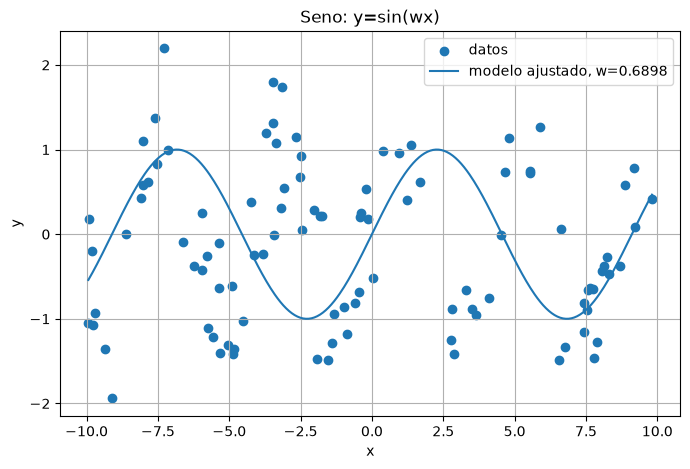

In [13]:
def predecir(x_valores, w_valor, tipo_modelo):
    if tipo_modelo == "lineal":
        return w_valor * x_valores
    elif tipo_modelo == "exponencial":
        return np.exp(w_valor * x_valores)
    elif tipo_modelo == "seno":
        return np.sin(w_valor * x_valores)
    else:
        raise ValueError("Modelo no reconocido")

# Graficar datos originales y modelo ajustado
for _, fila in tabla_perdida.iterrows():
    nombre = fila["Modelo"]
    w_opt = fila["Resultado"]
    _, df, tipo = perdidas[nombre]

    xs = df["x"].to_numpy()
    ys = df["y"].to_numpy()
    xs_plot = np.linspace(xs.min(), xs.max(), 400)
    ys_pred = predecir(xs_plot, w_opt, tipo)

    plt.figure(figsize=(8, 5))
    plt.scatter(xs, ys, label="datos")
    plt.plot(xs_plot, ys_pred, label=f"modelo ajustado, w={w_opt:.4f}")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(nombre)
    plt.legend()
    plt.grid(True)
    plt.show()


### Preguntas de la sección 4.3

**¿Cómo cambia la forma de $L(w)$ según el modelo?**

En el modelo lineal suele verse una pérdida con forma aproximadamente parabólica. En el exponencial puede crecer muy rápido para ciertos valores de $w$. En el modelo seno pueden aparecer varios mínimos locales por la periodicidad.

**¿Se observa un único mínimo en todos los casos?**

No necesariamente. El modelo lineal suele tener un mínimo claro. El modelo seno puede tener varios mínimos locales.

**¿Qué diferencias se observan en la convergencia?**

La convergencia depende de la forma de $L(w)$, del punto inicial y del learning rate. En pérdidas más irregulares o con varios mínimos, el resultado puede depender más de la condición inicial.

## 5. Bonus

### 5.1 Descenso por gradiente estocástico (SGD)

In [14]:
def crear_perdida_individual(xi, yi, tipo_modelo):
    if tipo_modelo == "lineal":
        y_pred = w * xi
    elif tipo_modelo == "exponencial":
        y_pred = exp(w * xi)
    elif tipo_modelo == "seno":
        y_pred = sin(w * xi)
    else:
        raise ValueError("Modelo no reconocido")

    return (y_pred - yi)**2


def sgd(df, tipo_modelo, w0=0.0, lr=0.01, tol=1e-6, max_iter=5000, seed=42):
    rng = np.random.default_rng(seed)
    w_actual = w0
    steps = [w_actual]

    xs = df["x"].to_numpy(dtype=float)
    ys = df["y"].to_numpy(dtype=float)
    N = len(df)

    for _ in range(max_iter):
        i = rng.integers(0, N)
        loss_i = crear_perdida_individual(xs[i], ys[i], tipo_modelo)
        grad_i = loss_i.derivative().eval(w_actual)
        w_nuevo = w_actual - lr * grad_i
        steps.append(w_nuevo)

        if abs(w_nuevo - w_actual) < tol:
            return w_nuevo, steps

        if not np.isfinite(w_nuevo):
            raise ValueError("SGD diverge: apareció un valor no finito.")

        w_actual = w_nuevo

    return w_actual, steps

filas_sgd = []
for nombre, (L, df, tipo) in perdidas.items():
    try:
        w_sgd, steps_sgd = sgd(df, tipo, w0=0.0 if tipo != "seno" else 1.0, lr=0.01, max_iter=5000)
        filas_sgd.append({
            "Modelo": nombre,
            "w SGD": w_sgd,
            "L(w SGD)": L.eval(w_sgd),
            "Iteraciones": len(steps_sgd) - 1,
            "Estado": "OK",
            "Aproximaciones": steps_sgd
        })
    except Exception as e:
        filas_sgd.append({
            "Modelo": nombre,
            "w SGD": np.nan,
            "L(w SGD)": np.nan,
            "Iteraciones": np.nan,
            "Estado": f"Error: {e}",
            "Aproximaciones": []
        })

tabla_sgd = pd.DataFrame(filas_sgd)
tabla_sgd[["Modelo", "w SGD", "L(w SGD)", "Iteraciones", "Estado"]]


/Users/mhc/Desktop/Optimizaci-n-Num-rica-en-una-Dimensi-n/abstractions/functions.py:69: RuntimeWarning: overflow encountered in exp
  return np.exp(self.f.eval(x))


,Modelo,w SGD,L(w SGD),Iteraciones,Estado
0,Lineal: y=wx,2.227942e+00,30.117148,5000,OK
1,Exponencial: y=e^(wx),1.782210e+274,inf,4,OK
2,Seno: y=sin(wx),1.454611e+00,0.280854,5000,OK


SGD suele tener una trayectoria más irregular porque usa un solo dato por iteración. Por eso puede fluctuar alrededor del mínimo, en vez de llegar de manera tan suave como el descenso por gradiente clásico.

### 5.2 Descenso por gradiente con learning rate variable

In [15]:
def descenso_gradiente_lr_variable(f: Function, x0: float, lr0: float = 0.1, tol: float = 1e-6, max_iter: int = 5000):
    g = f.derivative()
    x_actual = x0
    steps = [x_actual]

    for n in range(max_iter):
        lr_n = lr0 / (1 + n)   # learning rate variable
        grad = g.eval(x_actual)
        x_nuevo = x_actual - lr_n * grad
        steps.append(x_nuevo)

        if abs(x_nuevo - x_actual) < tol or abs(grad) < tol:
            return x_nuevo, steps

        if not np.isfinite(x_nuevo):
            raise ValueError("El método diverge: apareció un valor no finito.")

        x_actual = x_nuevo

    return x_actual, steps

filas_lr_variable = []
for x0 in [-3, 0.585, 4]:
    try:
        x_opt, steps = descenso_gradiente_lr_variable(f, x0=x0, lr0=0.1, max_iter=5000)
        filas_lr_variable.append({
            "x0": x0,
            "Resultado": x_opt,
            "f(resultado)": f.eval(x_opt),
            "Tipo": clasificar_extremo(f, x_opt),
            "Iteraciones": len(steps) - 1,
            "Estado": "OK",
            "Aproximaciones": steps
        })
    except Exception as e:
        filas_lr_variable.append({
            "x0": x0,
            "Resultado": np.nan,
            "f(resultado)": np.nan,
            "Tipo": "-",
            "Iteraciones": np.nan,
            "Estado": f"Error: {e}",
            "Aproximaciones": []
        })

tabla_lr_variable = pd.DataFrame(filas_lr_variable)
tabla_lr_variable[["x0", "Resultado", "f(resultado)", "Tipo", "Iteraciones", "Estado"]]


,x0,Resultado,f(resultado),Tipo,Iteraciones,Estado
0,-3.000,-2.322095,4.129725,mínimo local,955,OK
1,0.585,-0.470526,-1.753308,mínimo local,1027,OK
2,4.000,1.408131,0.216284,mínimo local,315,OK


Un learning rate variable puede ayudar a estabilizar el método: al comienzo da pasos más grandes y luego pasos más pequeños. Esto puede reducir oscilaciones, aunque no garantiza evitar todos los mínimos locales.

### 5.3 Producto de exponenciales vs suma

In [16]:
# Formulación producto para el modelo lineal: L_tilde(w) = prod exp(-(w*x_i - y_i)^2)
# Para maximizar con el mismo descenso, minimizamos -L_tilde(w).

def crear_producto_exponenciales(df):
    producto = 1
    for _, fila in df.iterrows():
        xi = float(fila["x"])
        yi = float(fila["y"])
        producto = producto * exp(-((w * xi - yi)**2))
    return producto

producto_lineal = crear_producto_exponenciales(df_linear)
menos_producto_lineal = -producto_lineal

# También usamos el logaritmo, porque es numéricamente más estable:
# log(producto) = - sum((w*x_i-y_i)^2)
log_producto_lineal = 0
for _, fila in df_linear.iterrows():
    xi = float(fila["x"])
    yi = float(fila["y"])
    log_producto_lineal = log_producto_lineal - (w * xi - yi)**2

menos_log_producto_lineal = -log_producto_lineal

resultados_producto = []
for nombre_objetivo, objetivo, lr in [
    ("Minimizar pérdida clásica", perdida_lineal, 0.05),
    ("Maximizar producto usando -producto", menos_producto_lineal, 0.001),
    ("Maximizar log-producto usando -log(producto)", menos_log_producto_lineal, 0.001),
]:
    fila = ejecutar("Descenso por gradiente", objetivo, {"x0": 0.0, "lr": lr, "tol": 1e-8, "max_iter": 10000})
    fila["Objetivo"] = nombre_objetivo
    fila["learning rate"] = lr
    resultados_producto.append(fila)

tabla_producto = pd.DataFrame(resultados_producto)
tabla_producto[["Objetivo", "learning rate", "Resultado", "f(resultado)", "Iteraciones", "Estado"]].rename(columns={"Resultado": "w obtenido"})


,Objetivo,learning rate,w obtenido,f(resultado),Iteraciones,Estado
0,Minimizar pérdida clásica,0.050,NaN,NaN,NaN,Error: El método diverge: apareció un valor no...
1,Maximizar producto usando -producto,0.001,0.0,-0.0,1.0,OK
2,Maximizar log-producto usando -log(producto),0.001,NaN,NaN,NaN,Error: El método diverge: apareció un valor no...


La formulación por producto busca el mismo valor de $w$ que la suma de cuadrados, porque maximizar el producto de exponenciales equivale a minimizar la suma de errores cuadrados. En la práctica, la versión con logaritmo suele ser más estable numéricamente, porque evita productos muy pequeños.